In [1]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import ScalarFormatter
from typing import Dict, Tuple, AnyStr
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import cartopy.util as cutil
import cartopy.crs as ccrs
from cdo import Cdo
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import torch
import pywt 
import glob
import cv2
import os

os.chdir('/Users/gabrieleaccarino/Workspace/metrics_reloaded')

#from library.candidate_metrics.wavelets.WAVESIMSV_Final import WaveSimSVFinal
#from library.candidate_metrics.wavelets.WAVESIMSV import WaveSimSV
#from library.candidate_metrics.wavelets.WAVESIM import WaveSim


%load_ext autoreload
%autoreload 2

In [2]:
PRECT_obs = xr.open_dataset('data/reanalysis/prect.mon.mean.72x144.nc') # mm/day
#T2M_obs = xr.open_dataset('data/reanalysis/air.2m.mon.mean.72x144.nc')#.sel(level=2.0)
SST_obs = xr.open_dataset('data/reanalysis/sst.mnmean.89x180.nc')

In [10]:
def ONI(sst_ds, lat, lon, climatology, reference_period):
    # Get climatology
    sst_clim = climatology
    
    # Extract SST data for reference period. Different ESMs use different names for SST
    ref_start, ref_end = reference_period
    var_name = 'tos' if 'tos' in sst_ds.data_vars else 'sst'
    sst = sst_ds[var_name].sel(time=slice(ref_start, ref_end))
    
    # calculate monthly anomaly
    sst_anom = sst.groupby('time.month') - sst_clim
    
    # extract SST data from the Nino 3.4 region
    sst_nino34 = sst_anom.sel(lat=lat, lon=lon)
    
    # calculate the mean values for the Nino 3.4 region
    nino34 = sst_nino34.mean(dim=["lat", "lon"])
    
    # calculate 3-month rolling mean of Nino 3.4 anomaly for the ONI
    oni = nino34.rolling(time=3, center=True).mean().dropna(dim='time')
    
    oni_bool = np.zeros_like(oni)

    for i in range(len(oni) - 4):
        if all(oni[i:i+5] >= 0.5):
            oni_bool[i:i+5] = 1
        elif all(oni[i:i+5] <= -0.5):
            oni_bool[i:i+5] = -1
            

    elnino_years = oni[oni_bool == 1].time.values
    lanina_years = oni[oni_bool == -1].time.values  

    return elnino_years, lanina_years, oni    

In [ ]:
#sst_clim  = SST_obs.sst.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean(dim='time')

#elnino_years, lanina_years, oni = ONI(SST_obs, lat=slice(5, -5), lon=slice(190, 240), climatology=sst_clim, reference_period=('1979-01', '2014-12'))

In [17]:
ESM_bias_prect, ESM_bias_sst = {}, {}
ESM = ['CESM2-FV2', 'FGOALS-g3', 'CMCC-CM2-HR4']
season = 'DJF'

seasons = {'DJF' : [12, 1, 2],
           'MAM' : [3, 4, 5],
           'JJA' : [6, 7, 8],
           'SON' : [9, 10, 11],
           'all' : np.arange(1, 13).tolist()}

pr_esm_base_path = f'data/CMIP6_monthly_data/remapped/pr/'
tos_esm_base_path = f'data/CMIP6_monthly_data/remapped/tos'

# 1. compute OBS SST climatology ('1979-01', '2014-12')
sst_obs_clim = SST_obs.sst.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean(dim='time')
prect_obs_clim = PRECT_obs.precip.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean('time')

elnino_years, lanina_years, oni = ONI(SST_obs, lat=slice(5, -5), lon=slice(190, 240), climatology=sst_obs_clim, reference_period=('1979-01', '2014-12'))
#print(elnino_years, lanina_years)

sst_obs_anom = SST_obs.groupby('time.month') - sst_obs_clim
SST_obs_NINO_values = sst_obs_anom.sel(time = elnino_years, method='nearest').where(sst_obs_anom.time.dt.month.isin(seasons[season])).mean('time').sst
SST_obs_NINA_values = sst_obs_anom.sel(time = lanina_years, method='nearest').where(sst_obs_anom.time.dt.month.isin(seasons[season])).mean('time').sst
ESM_bias_sst['OBS (SST)'] = SST_obs_NINO_values - SST_obs_NINA_values

prect_obs_anom = PRECT_obs.precip.groupby('time.month') - prect_obs_clim
PRECT_obs_NINO_values = prect_obs_anom.sel(time = elnino_years, method='nearest').where(prect_obs_anom.time.dt.month.isin(seasons[season])).mean('time')
PRECT_obs_NINA_values = prect_obs_anom.sel(time = lanina_years, method='nearest').where(prect_obs_anom.time.dt.month.isin(seasons[season])).mean('time')
ESM_bias_prect['OBS (GPCP)'] = PRECT_obs_NINO_values - PRECT_obs_NINA_values

# find the positive and negative ONI based on SST
for esm in ESM:
    print(f'Processing : {esm}')
    pr_esm_path = sorted(glob.glob(f'{pr_esm_base_path}/{esm}_pr_*.nc'))[0]
    pr_esm_df = xr.open_dataset(pr_esm_path)
    pr_clim = pr_esm_df.pr.sel(time=slice('1979-01', '2014-12')).groupby('time.month').mean('time')
    
    tos_esm_path = glob.glob(f'{tos_esm_base_path}/{esm}_tos_*.nc')[0]
    tos_esm_df = xr.open_dataset(tos_esm_path)
    tos_esm_clim = tos_esm_df.tos.groupby('time.month').mean(dim='time')
    
    # 2. for each ESM compute the positive and negative ONI index and extract years
    elnino_years, lanina_years, oni = ONI(tos_esm_df, lat=slice(5, -5), lon=slice(190, 240), climatology=tos_esm_clim, reference_period=('1979-01', '2014-12'))
    
    tos_anom = tos_esm_df.groupby('time.month') - tos_esm_clim
    SST_ESM_NINO_values = tos_anom.sel(time=elnino_years, method='nearest').where(tos_anom.time.dt.month.isin(seasons[season])).mean('time').tos
    SST_ESM_NINA_values = tos_anom.sel(time=lanina_years, method='nearest').where(tos_anom.time.dt.month.isin(seasons[season])).mean('time').tos
    ESM_bias_sst[esm] = SST_ESM_NINO_values - SST_ESM_NINA_values
    
    pr_anom = pr_esm_df.groupby('time.month') - pr_clim
    PRECT_ESM_NINO_values = pr_anom.sel(time=elnino_years, method='nearest').where(pr_anom.time.dt.month.isin(seasons[season])).mean('time').pr * 86400
    PRECT_ESM_NINA_values = pr_anom.sel(time=lanina_years, method='nearest').where(pr_anom.time.dt.month.isin(seasons[season])).mean('time').pr * 86400
    ESM_bias_prect[esm] = PRECT_ESM_NINO_values - PRECT_ESM_NINA_values

Processing : CESM2-FV2
Processing : FGOALS-g3
Processing : CMCC-CM2-HR4


# El Niño - La Niña Spatial Composite Precipitation (*SEASON*)

<Figure size 2000x800 with 0 Axes>

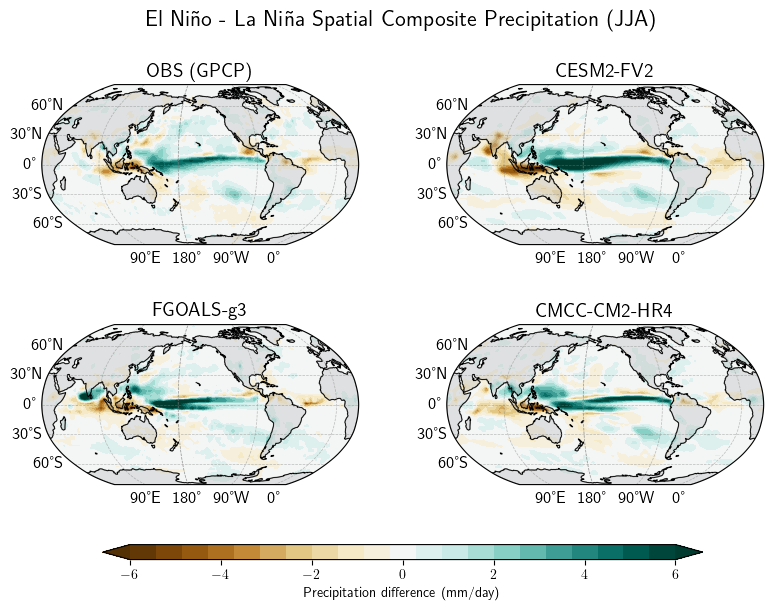

In [16]:
# Configure Matplotlib to use LaTeX
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(20, 8))

lat = PRECT_obs.latitude.values
lon = PRECT_obs.longitude.values

vmin = -6
vmax = +6
abs_max = max(abs(vmin), abs(vmax))
levels = np.linspace(-abs_max, abs_max, 22)
ticks = np.linspace(-abs_max, abs_max, num=7)

# other projections
#ccrs.PlateCarree(central_longitude=180), ccrs.Orthographic(central_longitude=180), ccrs.Robinson(central_longitude=180), ccrs.EckertIII(central_longitude=180), ccrs.EckertIV(central_longitude=180)

fig, axs = plt.subplots(2, 2, figsize=(12, 5), subplot_kw={'projection' : ccrs.Robinson(central_longitude=205)})  # Create GeoAxes with central longitude 180

for idx, ax in enumerate(axs.ravel()):
    key = list(ESM_bias_prect.keys())[idx]
    #if key == 'CESM2-WACCM':
    #    bias_, lon_, lat_ = cutil.add_cyclic(-1 * ESM_bias_prect[key], lon, lat)
    #else:
    bias_, lon_, lat_ = cutil.add_cyclic(ESM_bias_prect[key], lon, lat)
        
    #bias_plot = ax[0].pcolormesh(lon, lat, prect_obs_bias, transform=ccrs.PlateCarree(), cmap="BrBG", vmin=vmin, vmax=vmax) #RdBu_r
    im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap='BrBG', extend='both', transform=ccrs.PlateCarree())
    #ax.set_title(f"{key} (Niño - Niña)", fontsize=16)
    ax.set_title(f"{key}", fontsize=14)
    ax.set_facecolor("white")  # Set white background for spatial plots
    ax.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    #ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor='#B1B2B4', alpha=0.3, zorder=1)

    # panel letter
    #axs[idx].annotate(f'( {panels[idx]} )', xy=(2, 5), xytext=(10, 22), bbox=dict(boxstyle="square,pad=0.4", fc="white", ec="black", linewidth=0))

    # cbar (one for each subplot)
    #cbar = plt.colorbar(bias_plot, ax=ax, orientation="horizontal", pad=0.1, aspect=40)
    #cbar.set_label(f"{key} (mm/day)", fontsize=14)
    #cbar.ax.tick_params(labelsize=10)  # Increase label size

    longitude_ticks = mticker.MultipleLocator(base=90.0) # long ticks every 90 deg
    gl = ax.gridlines(draw_labels=True, xlocs=longitude_ticks, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#fig.suptitle('Composite ENSO Precipitation Difference (El Niño - La Niña)', fontsize=16, y=1.05)
fig.suptitle(f'El Niño - La Niña Spatial Composite Precipitation ({season})', fontsize=16, y=1.05)
#fig.suptitle('Precipitation Difference (DJF La Niña - interannual)', fontsize=16, y=1.05)
#fig.suptitle('Precipitation Difference (DJF El Niño - interannual)', fontsize=16, y=1.05)

# single colorbar
cax = fig.add_axes([0.25, -0.05, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(im, ax=axs.tolist(), cax=cax,
                    orientation='horizontal', pad=0.05,
                    aspect=60, shrink=0.9, label='Precipitation difference (mm/day)')
cbar.set_ticks(ticks)

#plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9, wspace=-0.4, hspace=0.5)
#plt.tight_layout()
plt.show()

# El Niño - La Niña Spatial Composite SST (*SEASON*)

In [18]:
colors = ['RGB(118,39,230)', 'RGB(25,6,241)', 'RGB(49,71,226)', 'RGB(69,116,228)', 'RGB(71,149,247)', 'RGB(86,188,249)', 'RGB(135,198,238)', 'RGB(188,222,242)',
          'RGB(254,248,156)', 'RGB(248,216,82)', 'RGB(243,174,61)', 'RGB(238,129,49)', 'RGB(235,70,38)', 'RGB(214,46,31)', 'RGB(192,49,40)', 'RGB(244,180,179)']

NORMALIZED_COLORS = []
for color in colors:
    R, G, B = color.strip('RGB(').strip(')').split(',')
    #colors_normalized.append(f"RGB({int(R)/255},{int(G)/255},{int(B)/255})")
    # convert 
    NORMALIZED_COLORS.append((int(R)/255,int(G)/255,int(B)/255))

<Figure size 2000x800 with 0 Axes>

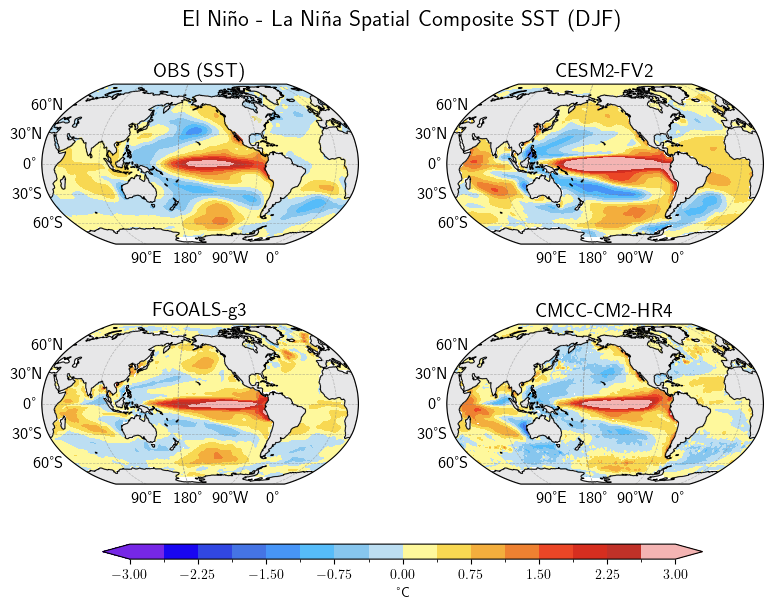

In [19]:
# Configure Matplotlib to use LaTeX
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

fig = plt.figure(figsize=(20, 8))

lat = SST_obs.lat.values
lon = SST_obs.lon.values

vmin = -3
vmax = 3
abs_max = max(abs(vmin), abs(vmax))
#levels = np.linspace(-abs_max, abs_max, 16)
#ticks = np.linspace(-abs_max, abs_max, num=7)
levels = np.linspace(vmin, vmax, 17)
ticks = np.linspace(vmin, vmax, num=7)

# other projections
#ccrs.PlateCarree(central_longitude=180), ccrs.Orthographic(central_longitude=180), ccrs.Robinson(central_longitude=180), ccrs.EckertIII(central_longitude=180), ccrs.EckertIV(central_longitude=180)

fig, axs = plt.subplots(2, 2, figsize=(12, 5), subplot_kw={'projection' : ccrs.Robinson(central_longitude=205)})  # Create GeoAxes with central longitude 180

cmap = ListedColormap(NORMALIZED_COLORS)
color_levels = [-3, -1.5, -0.5, 0.0, 0.5, 1.5, 3]
norm = BoundaryNorm(levels, ncolors=cmap.N) #, extend='both')

for idx, ax in enumerate(axs.ravel()):
    key = list(ESM_bias_sst.keys())[idx]

    bias_, lon_, lat_ = cutil.add_cyclic(ESM_bias_sst[key], lon, lat)
        
    #bias_plot = ax[0].pcolormesh(lon, lat, prect_obs_bias, transform=ccrs.PlateCarree(), cmap="BrBG", vmin=vmin, vmax=vmax) #RdBu_r
    #im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
    im = ax.contourf(lon_, lat_, bias_, levels=levels, cmap=cmap, norm=norm, extend='both', transform=ccrs.PlateCarree())
    #ax.set_title(f"{key} (Niño - Niña)", fontsize=16)
    ax.set_title(f"{key}", fontsize=14)
    ax.set_facecolor("white")  # Set white background for spatial plots
    ax.coastlines(resolution='110m', linewidth=0.6, edgecolor="black", alpha=1.0)
    #ax.add_feature(cfeature.BORDERS, linestyle=":", alpha=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor='#B1B2B4', alpha=0.3, zorder=1)

    # panel letter
    #axs[idx].annotate(f'( {panels[idx]} )', xy=(2, 5), xytext=(10, 22), bbox=dict(boxstyle="square,pad=0.4", fc="white", ec="black", linewidth=0))

    # cbar (one for each subplot)
    #cbar = plt.colorbar(bias_plot, ax=ax, orientation="horizontal", pad=0.1, aspect=40)
    #cbar.set_label(f"{key} (mm/day)", fontsize=14)
    #cbar.ax.tick_params(labelsize=10)  # Increase label size

    longitude_ticks = mticker.MultipleLocator(base=90.0) # long ticks every 90 deg
    gl = ax.gridlines(draw_labels=True, xlocs=longitude_ticks, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

fig.suptitle(f'El Niño - La Niña Spatial Composite SST ({season})', fontsize=16, y=1.05)

# single colorbar
cax = fig.add_axes([0.25, -0.05, 0.5, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(im, ax=axs.tolist(), cax=cax,
                    #ticks = color_levels, ####
                    orientation='horizontal', pad=0.05,
                    aspect=60, shrink=0.9, label='°C', 
                    format=ScalarFormatter()) ####
#cbar.set_ticks(ticks)

#plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9, wspace=-0.4, hspace=0.5)
#plt.tight_layout()
plt.show()